In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.mixture import GaussianMixture
import joblib
import random as rn

In [30]:
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
rn.seed(RANDOM_SEED)

In [31]:
BATCH_SIZE = 256
LATENT_DIM = 4

In [32]:
patients = {
    1: ['Data/organized_fcs_data1a.csv', 'Data/organized_fcs_data1b.csv', 'Data/organized_fcs_data1c.csv'],
    2: ['Data/organized_fcs_data2a.csv', 'Data/organized_fcs_data2b.csv', 'Data/organized_fcs_data2c.csv'],
    3: ['Data/organized_fcs_data3a.csv', 'Data/organized_fcs_data3b.csv', 'Data/organized_fcs_data3c.csv'],
    4: ['Data/organized_fcs_data4a.csv', 'Data/organized_fcs_data4b.csv', 'Data/organized_fcs_data4c.csv'],
    5: ['Data/organized_fcs_data5a.csv', 'Data/organized_fcs_data5b.csv', 'Data/organized_fcs_data5c.csv'],
    6: ['Data/organized_fcs_data6a.csv', 'Data/organized_fcs_data6b.csv', 'Data/organized_fcs_data6c.csv'],
    7: ['Data/organized_fcs_data7.csv'],
    8: ['Data/organized_fcs_data8a.csv', 'Data/organized_fcs_data8b.csv', 'Data/organized_fcs_data8c.csv'],
    9: ['Data/organized_fcs_data9a.csv', 'Data/organized_fcs_data9b.csv'],
    10: ['Data/organized_fcs_data10a.csv', 'Data/organized_fcs_data10b.csv', 'Data/organized_fcs_data10c.csv'],
    11: ['Data/organized_fcs_data11.csv'],
    12: ['Data/organized_fcs_data12a.csv', 'Data/organized_fcs_data12b.csv', 'Data/organized_fcs_data12c.csv']
}

In [33]:
training_ids = [1, 2, 3, 4, 5, 6]
test_ids = [7, 8, 9, 10, 11, 12]

In [34]:
def load_and_concatenate(ids):
    all_data = []
    for pid in ids:
        dfs = [pd.read_csv(fp).drop(columns=['Time'], errors='ignore') for fp in patients[pid]]
        all_data.append(pd.concat(dfs))
    return pd.concat(all_data, ignore_index=True)

In [35]:
train_df = load_and_concatenate(training_ids)
test_df = load_and_concatenate(test_ids)

In [9]:
pipeline = Pipeline([('scaler', MinMaxScaler())])
pipeline.fit(train_df)
X_train = pipeline.transform(train_df)
X_test = pipeline.transform(test_df)

In [10]:
class CustomDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

In [11]:
train_loader = DataLoader(CustomDataset(X_train), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(CustomDataset(X_test), batch_size=BATCH_SIZE, shuffle=False)

In [36]:
input_dim = X_train.shape[1]

In [37]:
class VarAutoEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim=4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16), nn.ELU(),
            nn.Linear(16, 8), nn.ELU(),
            nn.Linear(8, 4), nn.ELU(),
        )
        self.fc_mu = nn.Linear(4, latent_dim)
        self.fc_log_var = nn.Linear(4, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 4), nn.ELU(),
            nn.Linear(4, 8), nn.ELU(),
            nn.Linear(8, 16), nn.ELU(),
            nn.Linear(16, input_dim), nn.ELU()
        )

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        encoded = self.encoder(x)
        mu = self.fc_mu(encoded)
        log_var = self.fc_log_var(encoded)
        z = self.reparameterize(mu, log_var)
        decoded = self.decoder(z)
        return decoded, mu, log_var

In [38]:
vae = VarAutoEncoder(input_dim=input_dim, latent_dim=LATENT_DIM)
vae.load_state_dict(torch.load("vae_4dim_6_final.pth"))
vae.eval()

VarAutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=14, out_features=16, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=4, bias=True)
    (5): ELU(alpha=1.0)
  )
  (fc_mu): Linear(in_features=4, out_features=4, bias=True)
  (fc_log_var): Linear(in_features=4, out_features=4, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=4, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=4, out_features=8, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=8, out_features=16, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=16, out_features=14, bias=True)
    (7): ELU(alpha=1.0)
  )
)

In [39]:
#latent space extraction 
def extract_latent(model, loader):
    latents = []
    model.eval()
    with torch.no_grad():
        for x in loader:
            enc = model.encoder(x)
            mu = model.fc_mu(enc)
            latents.append(mu.numpy())
    return np.vstack(latents)

latent_train = extract_latent(vae, train_loader)
latent_test = extract_latent(vae, test_loader)

In [40]:
print(f"Train latent shape: {latent_train.shape}")
print(f"Test latent shape: {latent_test.shape}")

Train latent shape: (27206732, 4)
Test latent shape: (20669340, 4)


In [ ]:
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
gmm.fit(latent_train)
joblib.dump(gmm, 'VM_4Comp.pkl')

# gmm = joblib.load('VM_4Comp.pkl')

GaussianMixture(n_components=4, random_state=42)

In [42]:
healthy_scores = gmm.score_samples(latent_train)
unhealthy_scores = gmm.score_samples(latent_test)

In [43]:
threshold = np.percentile(healthy_scores, 1)
print(threshold)

9.465618842867434


In [44]:
anomalies = unhealthy_scores < threshold
healthy_anomalies = healthy_scores < threshold

In [45]:
def load_patient_data(patient_ids):
    all_data = []
    for pid in patient_ids:
        dfs = [pd.read_csv(fp).drop(columns=['Time'], errors='ignore') for fp in patients[pid]]
        all_data.append(pd.concat(dfs))
    return pd.concat(all_data, ignore_index=True)

In [46]:
print("\nMRD percentage for each unhealthy patient:")
unhealthy_patient_ids = [7, 8, 9, 10, 11, 12]
start_idx = 0

predicted_percentages = []
actual_percentages = [3.28, 1.2, 9.3, 2.17, 14.6, 4.2] 

for pid in unhealthy_patient_ids:
    patient_data = load_patient_data([pid])
    patient_cells = len(patient_data)
    patient_anomalies = anomalies[start_idx:start_idx + patient_cells]
    mrd_percent = (np.sum(patient_anomalies) / patient_cells) * 100
    predicted_percentages.append(round(mrd_percent, 2))
    print(f"Patient {pid}: {mrd_percent:.4f}% MRD")
    start_idx += patient_cells


MRD percentage for each unhealthy patient:
Patient 7: 13.1588% MRD
Patient 8: 1.4273% MRD
Patient 9: 6.4137% MRD
Patient 10: 1.2757% MRD
Patient 11: 5.0135% MRD
Patient 12: 6.3997% MRD


In [47]:
print("\nMRD percentage for each healthy patient:")
healthy_patient_ids = [1, 2, 3, 4, 5, 6]
start_idx = 0

for pid in healthy_patient_ids:
    patient_data = load_patient_data([pid])
    patient_cells = len(patient_data)
    patient_anomalies = healthy_anomalies[start_idx:start_idx + patient_cells]
    mrd_percent = (np.sum(patient_anomalies) / patient_cells) * 100
    print(f"Patient {pid}: {mrd_percent:.4f}% MRD")
    start_idx += patient_cells



MRD percentage for each healthy patient:
Patient 1: 0.9369% MRD
Patient 2: 0.7072% MRD
Patient 3: 1.0161% MRD
Patient 4: 2.3456% MRD
Patient 5: 0.6677% MRD
Patient 6: 0.6113% MRD


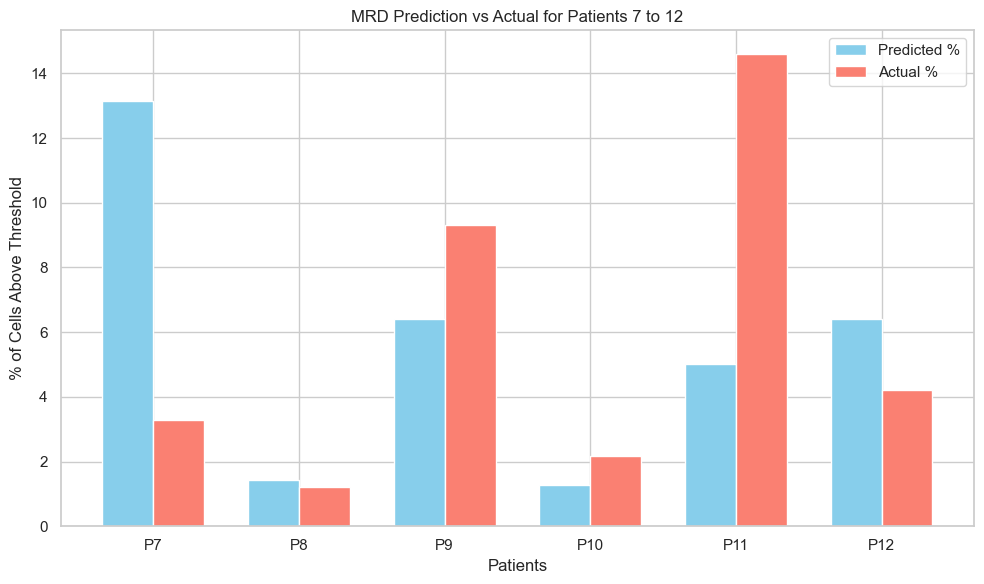

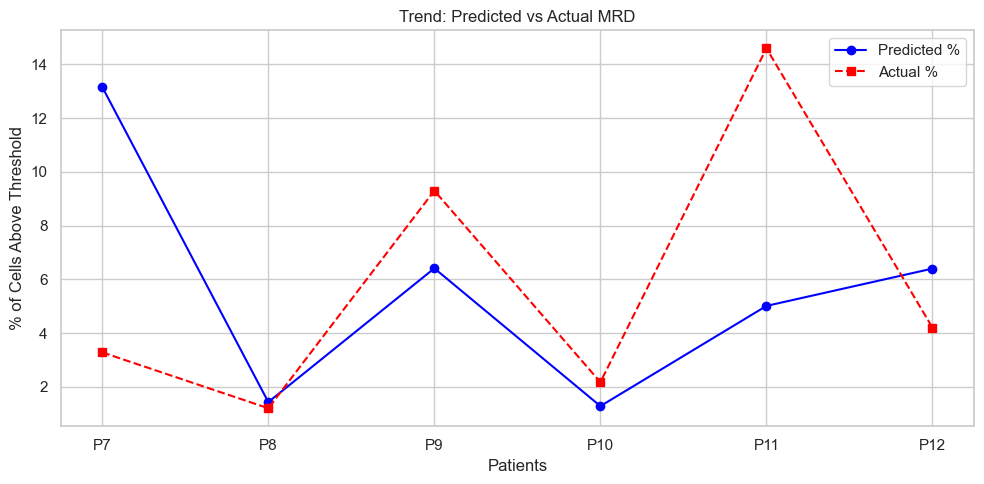

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

patients = ['P7', 'P8', 'P9', 'P10', 'P11', 'P12']
df_plot = pd.DataFrame({
    'Patient': patients,
    'Predicted': predicted_percentages,
    'Actual': actual_percentages
})

# Bar Plot
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(patients))

plt.bar(x - bar_width/2, df_plot['Predicted'], bar_width, label='Predicted %', color='skyblue')
plt.bar(x + bar_width/2, df_plot['Actual'], bar_width, label='Actual %', color='salmon')

plt.xlabel('Patients')
plt.ylabel('% of Cells Above Threshold')
plt.title('MRD Prediction vs Actual for Patients 7 to 12')
plt.xticks(ticks=x, labels=patients)
plt.legend()
plt.tight_layout()
plt.show()

# Line Plot
plt.figure(figsize=(10, 5))
plt.plot(patients, predicted_percentages, marker='o', label='Predicted %', linestyle='-', color='blue')
plt.plot(patients, actual_percentages, marker='s', label='Actual %', linestyle='--', color='red')

plt.xlabel('Patients')
plt.ylabel('% of Cells Above Threshold')
plt.title('Trend: Predicted vs Actual MRD')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
